In [1]:
import os
os.environ.get('TRAJECTORY_WORKDIR'), os.listdir('/workspace')

('/workspace/b34b97ec-fd98-4563-824d-e3ee1ae1dcb2',
 ['.kernel_meta_b34b97ec-fd98-4563-824d-e3ee1ae1dcb2',
  'lost+found',
  'b34b97ec-fd98-4563-824d-e3ee1ae1dcb2'])

In [2]:
wd = os.environ['TRAJECTORY_WORKDIR']
os.listdir(wd)

['starter_board_summary.json',
 'test_module_starter.kicad_sch',
 'test_module_starter.kicad_pro',
 '.kernel_llm_logs_1.txt',
 '.config',
 'test_module_starter.kicad_pcb',
 'test_module_starter.svg',
 '.prompts',
 'memory',
 'build_starter_board.py']

In [3]:
import json
with open(f"{wd}/starter_board_summary.json") as f:
    summary = json.load(f)
print(json.dumps(summary, indent=2)[:3000])

{
  "board": "test_module_starter.kicad_pcb",
  "schematic": "test_module_starter.kicad_sch",
  "project": "test_module_starter.kicad_pro",
  "components": 14,
  "nets": 20,
  "outline_mm": [
    82.28,
    112.95
  ],
  "power_nets": [
    "+12V",
    "+3V3",
    "+5V",
    "GND"
  ],
  "bom": [
    {
      "ref": "J1",
      "part": "Barrel_Jack_12V",
      "kind": "module",
      "pins": 2,
      "body_mm": [
        14.0,
        11.0
      ],
      "model": null,
      "source": "Adafruit #373 2.1 mm DC barrel-jack breakout (datasheet)"
    },
    {
      "ref": "U1",
      "part": "D24V22F5_Buck",
      "kind": "module",
      "pins": 5,
      "body_mm": [
        12.7,
        10.16
      ],
      "model": "hardware/vendor-files/pololu-2858-d24v22f5/cad/d24v22fx-step-down-voltage-regulator.step",
      "source": "Pololu #2858 0.5x0.4 in PCB; STEP envelope 19.5x20.7x13.8 mm"
    },
    {
      "ref": "C1",
      "part": "Cap_Polar",
      "kind": "passive",
      "pins": 2,
     

In [4]:
print(json.dumps(summary, indent=2)[3000:6000])

35-tic-t500/cad/tic-stepper-motor-controller-models.zip"
    },
    {
      "ref": "C3",
      "part": "Cap_Polar",
      "kind": "passive",
      "pins": 2,
      "body_mm": [
        8.5,
        8.5
      ],
      "model": null,
      "source": "generic radial electrolytic, \u00d88 mm body"
    },
    {
      "ref": "SR1",
      "part": "Shunt_Regulator",
      "kind": "module",
      "pins": 2,
      "body_mm": [
        24.13,
        10.16
      ],
      "model": "hardware/vendor-files/pololu-3776-shunt-regulator-9w/cad/shunt-regulator.step",
      "source": "Pololu #3776 0.95x0.4 in PCB; STEP envelope 28.6x21.2x13.8 mm"
    },
    {
      "ref": "M2",
      "part": "Stepper_4wire",
      "kind": "connector",
      "pins": 4,
      "body_mm": null,
      "model": null,
      "source": "off-board StepperOnline 11HS18-0674S NEMA-11 28x28x45 mm; STEP in hardware/vendor-files/stepperonline-11hs18-0674s/cad/11HS18-0674S.STEP"
    },
    {
      "ref": "M3",
      "part": "Servo_3pin",

In [5]:
import math

# Recompute the packing manually to verify numbers and quantify efficiency
PITCH = 2.54
ROW_GAP = 7.62
PAD_SIZE = 1.7
SILK_MARGIN = 1.0
CRTYD_CLEARANCE = 0.5
PLACE_GAP = 1.5
TARGET_ASPECT = 1.15
EDGE_MARGIN = 5.0

PINOUTS = {
    "Barrel_Jack_12V": {"left": ["+12V", "GND"], "right": []},
    "D24V22F5_Buck": {"left": ["VIN", "GND_IN", "SHDN"], "right": ["VOUT", "GND_OUT"]},
    "Cap_Polar": {"left": ["+"], "right": ["-"]},
    "Shunt_Regulator": {"left": ["+"], "right": ["-"]},
    "Pi_Pico_W": {"left": ["GP0","GP1","GP2","GP3","GP4","GP5","GP6","GP7","GP10","GP11","GP14","GP15"],
                  "right": ["VSYS","GND","3V3"]},
    "DRV2605L_Breakout": {"left": ["VIN","GND","SDA","SCL","IN_TRIG","EN"], "right": ["OUT+","OUT-"]},
    "DRV8871_Breakout": {"left": ["VM","GND","IN1","IN2"], "right": ["OUT1","OUT2"]},
    "Tic_T500": {"left":["SCL","SDA","TX","RX","ERR"],"right":["VIN","GND","A1","A2","B1","B2"]},
    "Stepper_4wire":{"left":["A1","A2"],"right":["B1","B2"]},
    "Servo_3pin":{"left":["+5V","GND","SIG"],"right":[]},
    "ERM_Motor":{"left":["+"],"right":["-"]},
    "Solenoid":{"left":["+"],"right":["-"]},
}

PACKAGES = {
    "Barrel_Jack_12V":(14.0,11.0),"D24V22F5_Buck":(12.7,10.16),"Cap_Polar":(8.5,8.5),
    "Shunt_Regulator":(24.13,10.16),"Pi_Pico_W":(51.0,21.0),"DRV2605L_Breakout":(17.78,16.51),
    "DRV8871_Breakout":(20.32,24.13),"Tic_T500":(25.4,15.24),
    "Stepper_4wire":None,"Servo_3pin":None,"ERM_Motor":None,"Solenoid":None,
}

NETLIST_REFS = [
    ("J1","Barrel_Jack_12V"),("U1","D24V22F5_Buck"),("C1","Cap_Polar"),("C2","Cap_Polar"),
    ("U2","Pi_Pico_W"),("U3","DRV2605L_Breakout"),("M1","ERM_Motor"),("U4","DRV8871_Breakout"),
    ("SOL1","Solenoid"),("U5","Tic_T500"),("C3","Cap_Polar"),("SR1","Shunt_Regulator"),
    ("M2","Stepper_4wire"),("M3","Servo_3pin"),
]

def body_ext(lib):
    cols = PINOUTS[lib]
    nrows = max(len(cols["left"]), len(cols["right"])) or 1
    half_x = ROW_GAP/2
    pad_hw = half_x + PAD_SIZE/2 + SILK_MARGIN
    pad_hh = (nrows-1)/2*PITCH + PAD_SIZE/2 + SILK_MARGIN
    body = PACKAGES[lib]
    if body is not None:
        return max(pad_hw, body[0]/2), max(pad_hh, body[1]/2)
    return pad_hw, pad_hh

def crty(lib):
    hw,hh = body_ext(lib)
    return hw+CRTYD_CLEARANCE, hh+CRTYD_CLEARANCE

sizes = [(r, *crty(l)) for r,l in NETLIST_REFS]
total_area = sum((2*hw)*(2*hh) for _,hw,hh in sizes)
widest = max(2*hw for _,hw,_ in sizes)
target_w = max(widest, math.sqrt(total_area)*TARGET_ASPECT)

print(f"Total courtyard area: {total_area:.1f} mm^2")
print(f"Widest part: {widest:.2f} mm")
print(f"sqrt(area)*1.15 = {math.sqrt(total_area)*TARGET_ASPECT:.2f} mm")
print(f"target_w = {target_w:.2f} mm")

pos = {}
cx=cy=row_h=0.0
for r,hw,hh in sizes:
    w,h=2*hw,2*hh
    if cx>0 and cx+w>target_w:
        cy += row_h + PLACE_GAP
        cx = row_h = 0.0
    pos[r]=(cx+hw, cy+hh, hw, hh)
    cx += w + PLACE_GAP
    row_h = max(row_h,h)

xs0=min(p[0]-p[2] for p in pos.values()); xs1=max(p[0]+p[2] for p in pos.values())
ys0=min(p[1]-p[3] for p in pos.values()); ys1=max(p[1]+p[3] for p in pos.values())
inner_w = xs1-xs0; inner_h = ys1-ys0
board_w = inner_w + 2*EDGE_MARGIN; board_h = inner_h + 2*EDGE_MARGIN
print(f"\nInner bbox (courtyards): {inner_w:.2f} x {inner_h:.2f}  area={inner_w*inner_h:.1f}")
print(f"Board outline: {board_w:.2f} x {board_h:.2f}  area={board_w*board_h:.1f}")
print(f"Aspect: {board_w/board_h:.3f}")
print(f"Courtyard fill fraction (of inner bbox): {total_area/(inner_w*inner_h)*100:.1f}%")
print(f"Courtyard fill fraction (of full board): {total_area/(board_w*board_h)*100:.1f}%")

# Where each part landed
import textwrap
print("\nPlacements (ref, x, y, courtyard wxh):")
for r,(x,y,hw,hh) in pos.items():
    print(f"  {r:5s}  x={x:6.2f}  y={y:6.2f}  {2*hw:5.2f} x {2*hh:5.2f}")


Total courtyard area: 4311.2 mm^2
Widest part: 52.00 mm
sqrt(area)*1.15 = 75.51 mm
target_w = 75.51 mm

Inner bbox (courtyards): 72.28 x 102.95  area=7441.2
Board outline: 82.28 x 112.95  area=9293.5
Aspect: 0.728
Courtyard fill fraction (of inner bbox): 57.9%
Courtyard fill fraction (of full board): 46.4%

Placements (ref, x, y, courtyard wxh):
  J1     x=  7.50  y=  6.00  15.00 x 12.00
  U1     x= 23.35  y=  5.58  13.70 x 11.16
  C1     x= 37.86  y=  4.75  12.32 x  9.50
  C2     x= 51.68  y=  4.75  12.32 x  9.50
  U2     x= 26.00  y= 29.82  52.00 x 32.64
  U3     x= 62.89  y= 22.26  18.78 x 17.51
  M1     x=  6.16  y= 49.99  12.32 x  4.70
  U4     x= 24.48  y= 60.20  21.32 x 25.13
  SOL1   x= 42.80  y= 49.99  12.32 x  4.70
  U5     x= 13.20  y= 82.97  26.40 x 17.40
  C3     x= 34.06  y= 79.02  12.32 x  9.50
  SR1    x= 54.28  y= 79.85  25.13 x 11.16
  M2     x=  6.16  y= 96.79  12.32 x  7.24
  M3     x= 19.98  y= 98.06  12.32 x  9.78


In [6]:
# Let's also estimate ratsnest total length under current placement vs. some
# alternative groupings to give a quantitative argument for grouping.
from math import hypot

# Map ref -> lib
ref_to_lib = dict(NETLIST_REFS)

# Build pin world coords (use board pad locations)
pad_world = {}  # ref -> list of (pin_name, (x,y), net)

NETLIST_PINS = {
 "J1":[("+12V","+12V"),("GND","GND")],
 "U1":[("VIN","+12V"),("GND_IN","GND"),("SHDN","+12V"),("VOUT","+5V"),("GND_OUT","GND")],
 "C1":[("+","+12V"),("-","GND")],
 "C2":[("+","+5V"),("-","GND")],
 "U2":[("VSYS","+5V"),("GND","GND"),("3V3","+3V3"),("GP0","I2C_SDA"),("GP1","I2C_SCL"),
       ("GP4","STP_TX"),("GP5","STP_RX"),("GP10","SOL_IN1"),("GP11","SOL_IN2"),
       ("GP15","SERVO_SIG"),("GP14","HAPT_EN")],
 "U3":[("VIN","+3V3"),("GND","GND"),("SDA","I2C_SDA"),("SCL","I2C_SCL"),("EN","HAPT_EN"),
       ("IN_TRIG","HAPT_EN"),("OUT+","VIB_A"),("OUT-","VIB_B")],
 "M1":[("+","VIB_A"),("-","VIB_B")],
 "U4":[("VM","+12V"),("GND","GND"),("IN1","SOL_IN1"),("IN2","SOL_IN2"),
       ("OUT1","SOL_A"),("OUT2","SOL_B")],
 "SOL1":[("+","SOL_A"),("-","SOL_B")],
 "U5":[("RX","STP_TX"),("TX","STP_RX"),("VIN","+12V"),("GND","GND"),
       ("A1","STP_A1"),("A2","STP_A2"),("B1","STP_B1"),("B2","STP_B2")],
 "C3":[("+","+12V"),("-","GND")],
 "SR1":[("+","+12V"),("-","GND")],
 "M2":[("A1","STP_A1"),("A2","STP_A2"),("B1","STP_B1"),("B2","STP_B2")],
 "M3":[("+5V","+5V"),("GND","GND"),("SIG","SERVO_SIG")],
}

def pad_positions(lib):
    cols = PINOUTS[lib]
    left, right = cols["left"], cols["right"]
    n_rows = max(len(left), len(right)) or 1
    half_x = ROW_GAP/2
    def col_y(i,n): return (i-(n-1)/2)*PITCH
    out = {}
    for i,p in enumerate(left):
        out[p] = (-half_x, col_y(i, len(left)))
    for i,p in enumerate(right):
        out[p] = (half_x, col_y(i, len(right)))
    return out

def compute_ratsnest_total(positions):
    # net -> list of (x,y)
    net_pins = {}
    for ref, lib in NETLIST_REFS:
        cx, cy = positions[ref][:2]
        local = pad_positions(lib)
        for pin_name, net in NETLIST_PINS[ref]:
            if pin_name not in local: continue
            lx,ly = local[pin_name]
            net_pins.setdefault(net, []).append((cx+lx, cy+ly))
    # Approximate MST length per net via nearest-insertion / use Prim's
    total = 0.0
    per_net = {}
    for net, pts in net_pins.items():
        if len(pts) < 2: 
            per_net[net]=0; continue
        # Prim's MST
        in_tree = {0}
        d = {i: hypot(pts[i][0]-pts[0][0], pts[i][1]-pts[0][1]) for i in range(1,len(pts))}
        net_len = 0.0
        while d:
            j = min(d, key=d.get)
            net_len += d[j]; in_tree.add(j); d.pop(j)
            for k in list(d):
                nd = hypot(pts[k][0]-pts[j][0], pts[k][1]-pts[j][1])
                if nd < d[k]: d[k]=nd
        per_net[net]=net_len
        total += net_len
    return total, per_net

total_cur, per_net_cur = compute_ratsnest_total(pos)
print(f"Current ratsnest MST length: {total_cur:.1f} mm")
print("Top 10 nets by length:")
for n,l in sorted(per_net_cur.items(), key=lambda x:-x[1])[:10]:
    print(f"  {n:12s} {l:6.1f} mm")


Current ratsnest MST length: 1057.8 mm
Top 10 nets by length:
  GND           200.5 mm
  +12V          138.2 mm
  +5V           113.4 mm
  VIB_A          70.6 mm
  VIB_B          62.6 mm
  STP_TX         60.9 mm
  SERVO_SIG      57.1 mm
  STP_RX         55.9 mm
  HAPT_EN        41.5 mm
  I2C_SDA        37.2 mm


In [7]:
# Try a hand-grouped alternative ordering: power-in cluster, MCU+I2C+haptic, motor-power cluster, off-board headers on edges
# We'll just reorder the NETLIST and re-pack to compare.
alt_order = [
  ("J1","Barrel_Jack_12V"),
  ("C1","Cap_Polar"),       # bulk 12V cap near jack
  ("U1","D24V22F5_Buck"),
  ("C2","Cap_Polar"),       # 5V cap near buck out
  ("SR1","Shunt_Regulator"),
  ("C3","Cap_Polar"),       # 12V cap near motor power
  ("U5","Tic_T500"),
  ("M2","Stepper_4wire"),
  ("U4","DRV8871_Breakout"),
  ("SOL1","Solenoid"),
  ("U2","Pi_Pico_W"),
  ("U3","DRV2605L_Breakout"),
  ("M1","ERM_Motor"),
  ("M3","Servo_3pin"),
]

def pack(order):
    sizes = [(r, *crty(l)) for r,l in order]
    total_area = sum((2*hw)*(2*hh) for _,hw,hh in sizes)
    widest = max(2*hw for _,hw,_ in sizes)
    target_w = max(widest, math.sqrt(total_area)*TARGET_ASPECT)
    pos = {}
    cx=cy=row_h=0.0
    for r,hw,hh in sizes:
        w,h=2*hw,2*hh
        if cx>0 and cx+w>target_w:
            cy += row_h + PLACE_GAP
            cx = row_h = 0.0
        pos[r]=(cx+hw, cy+hh, hw, hh)
        cx += w + PLACE_GAP
        row_h = max(row_h,h)
    return pos

pos_alt = pack(alt_order)
xs0=min(p[0]-p[2] for p in pos_alt.values()); xs1=max(p[0]+p[2] for p in pos_alt.values())
ys0=min(p[1]-p[3] for p in pos_alt.values()); ys1=max(p[1]+p[3] for p in pos_alt.values())
inner_w = xs1-xs0; inner_h = ys1-ys0
print(f"Alt-ordered inner bbox: {inner_w:.2f} x {inner_h:.2f}")

total_alt, per_net_alt = compute_ratsnest_total(pos_alt)
print(f"Alt ratsnest MST length: {total_alt:.1f} mm")
print(f"Reduction vs current: {(1-total_alt/total_cur)*100:.1f}%")
print("\nNet-by-net deltas (top changes):")
deltas = sorted([(n, per_net_cur[n]-per_net_alt[n]) for n in per_net_cur], key=lambda x:-x[1])
for n,d in deltas[:10]:
    print(f"  {n:12s}  cur={per_net_cur[n]:6.1f}  alt={per_net_alt[n]:6.1f}  saved={d:+.1f}")


Alt-ordered inner bbox: 72.28 x 102.95
Alt ratsnest MST length: 1145.1 mm
Reduction vs current: -8.3%

Net-by-net deltas (top changes):
  SERVO_SIG     cur=  57.1  alt=  12.8  saved=+44.3
  +12V          cur= 138.2  alt= 110.8  saved=+27.4
  +5V           cur= 113.4  alt= 102.8  saved=+10.6
  STP_TX        cur=  60.9  alt=  54.4  saved=+6.5
  HAPT_EN       cur=  41.5  alt=  41.5  saved=+0.0
  I2C_SDA       cur=  37.2  alt=  37.2  saved=+0.0
  I2C_SCL       cur=  37.2  alt=  37.2  saved=+0.0
  VIB_A         cur=  70.6  alt=  70.6  saved=+0.0
  VIB_B         cur=  62.6  alt=  62.6  saved=+0.0
  SOL_A         cur=  13.9  alt=  13.9  saved=+0.0


In [8]:
# Hmm, alt ratsnest grew. Let me also try a "MCU-centric" ordering: put Pico in middle row, with I2C/haptic + DRV8871 + Tic on adjacent rows.
# Issue: shelf packer is purely sequential — same-row vs different-row matters.
# Let me try a more aggressive grouping: power-rail-by-net domain.

alt2 = [
  # Row 1 (power input edge)
  ("J1","Barrel_Jack_12V"),("C1","Cap_Polar"),("U1","D24V22F5_Buck"),("C2","Cap_Polar"),
  ("SR1","Shunt_Regulator"),("C3","Cap_Polar"),
  # Row 2 (MCU centered, off-board headers will live on edges of board)
  ("U3","DRV2605L_Breakout"),("M1","ERM_Motor"),("U2","Pi_Pico_W"),("M3","Servo_3pin"),
  # Row 3 (motor power section)
  ("U4","DRV8871_Breakout"),("SOL1","Solenoid"),("U5","Tic_T500"),("M2","Stepper_4wire"),
]
pos_a2 = pack(alt2)
total_a2, per_net_a2 = compute_ratsnest_total(pos_a2)
xs0=min(p[0]-p[2] for p in pos_a2.values()); xs1=max(p[0]+p[2] for p in pos_a2.values())
ys0=min(p[1]-p[3] for p in pos_a2.values()); ys1=max(p[1]+p[3] for p in pos_a2.values())
print(f"alt2 bbox: {xs1-xs0:.1f} x {ys1-ys0:.1f}")
print(f"alt2 ratsnest: {total_a2:.1f} mm  (cur {total_cur:.1f})")
deltas = sorted([(n, per_net_cur[n]-per_net_a2[n]) for n in per_net_cur], key=lambda x:-x[1])
for n,d in deltas[:8]:
    print(f"  {n:12s}  cur={per_net_cur[n]:6.1f}  alt={per_net_a2[n]:6.1f}  saved={d:+.1f}")


alt2 bbox: 73.0 x 100.5
alt2 ratsnest: 1019.9 mm  (cur 1057.8)
  VIB_A         cur=  70.6  alt=  10.7  saved=+59.8
  +5V           cur= 113.4  alt=  66.5  saved=+46.9
  VIB_B         cur=  62.6  alt=  18.7  saved=+43.9
  STP_TX        cur=  60.9  alt=  40.6  saved=+20.3
  STP_RX        cur=  55.9  alt=  36.6  saved=+19.3
  SERVO_SIG     cur=  57.1  alt=  40.7  saved=+16.4
  I2C_SDA       cur=  37.2  alt=  27.6  saved=+9.7
  I2C_SCL       cur=  37.2  alt=  27.6  saved=+9.7


In [9]:
# So even within the same shelf packer, just reordering NETLIST grouped by power+function gives ~3.6% reduction in MST
# More importantly, the long offending nets (VIB, +5V, STP, SERVO, I2C) shorten dramatically.
# GND grew though — let's check
print("GND current:", per_net_cur["GND"], "alt2:", per_net_a2["GND"])
print("+12V current:", per_net_cur["+12V"], "alt2:", per_net_a2["+12V"])
# These are net-stars that touch many parts so they don't move much; that's expected.

# Now compute total pad area / drill density and confirm pad pitch viability
total_pads = sum(len(NETLIST_PINS[r]) for r,_ in NETLIST_REFS)
print(f"\nTotal nets driven: {total_pads} (but pads-per-part include unused pins too)")
total_pad_holes = 0
for r,lib in NETLIST_REFS:
    cols = PINOUTS[lib]
    total_pad_holes += len(cols["left"]) + len(cols["right"])
print(f"Total through-holes (pads): {total_pad_holes}")
# Board area
print(f"Through-hole density: {total_pad_holes/(82.28*112.95)*1000:.1f} pads / dm^2  (per cm^2: {total_pad_holes/(82.28*112.95)*100:.2f})")

# Min clearance vs hole diameter check: pads are 1.7 mm OD on 2.54 mm pitch -> 0.84 mm copper-to-copper gap (OK with 0.2 mm clearance rule)
print(f"\nPad copper-to-copper gap on 0.1\" pitch: {2.54-1.7:.2f} mm (rule: 0.2 mm Default, 0.3 mm Power)")
print(f"Tracks fitting between pads on 2.54 mm pitch with 0.25 mm trace: clearance left = {(2.54-1.7-2*0.2-0.25):.2f} mm at 0.2 mm clear")
print(f"Power class 0.6 mm trace between pads on 2.54 mm: {(2.54-1.7-2*0.3-0.6):.2f} mm  -> cannot fit between adjacent pads")


GND current: 200.51679993565014 alt2: 205.62122231267702
+12V current: 138.16976567879146 alt2: 164.69789846239058

Total nets driven: 59 (but pads-per-part include unused pins too)
Total through-holes (pads): 66
Through-hole density: 7.1 pads / dm^2  (per cm^2: 0.71)

Pad copper-to-copper gap on 0.1" pitch: 0.84 mm (rule: 0.2 mm Default, 0.3 mm Power)
Tracks fitting between pads on 2.54 mm pitch with 0.25 mm trace: clearance left = 0.19 mm at 0.2 mm clear
Power class 0.6 mm trace between pads on 2.54 mm: -0.36 mm  -> cannot fit between adjacent pads


In [10]:
# So the Power class track width (0.6 mm) + clearance (0.3 mm) cannot fit between adjacent 0.1" pads.
# That's a real concern — power needs to fan out around pads.

# Verify with current routing: 0.25 mm trace + 0.2 mm clearance leaves 0.19 mm slack — extremely tight, won't autoroute cleanly
# Industry rule: between 1.7 mm OD pads on 2.54 mm pitch, max trace ~0.25 mm with 0.2 mm clear is borderline.
# Recommendation: shrink pad size to ~1.5 mm or use 0.2 mm trace / 0.15 mm clearance for signal class.

# Check the +12V current capacity at 0.6 mm: external 1 oz copper, ~10 °C rise -> ~1.4 A
# Solenoid + steppers + buck input could exceed 1 A — DRV8871 sustained 1.5 A, Tic T500 up to 1.5 A.
# So 0.6 mm for +12V is marginal. Consider 1.0 mm + pour.

# Board outline check — what's a credible margin?
# 5 mm Edge.Cuts margin is fine for most fab houses. JLC requires ~5 mm if no V-cut.
# Note: no mounting holes! That's a manufacturability red flag.

# Save a comparative summary
result = {
  "current": {"board_mm": [82.28,112.95], "aspect": 0.728, "fill_inner": 0.579, "fill_outer": 0.464,
              "ratsnest_mm": total_cur, "long_nets": {n:per_net_cur[n] for n in ['GND','+12V','+5V']}},
  "alt2_grouped": {"board_mm": [73.0+10, 100.5+10], "ratsnest_mm": total_a2,
                   "long_nets": {n:per_net_a2[n] for n in ['GND','+12V','+5V']}},
}
print(json.dumps(result, indent=2))


{
  "current": {
    "board_mm": [
      82.28,
      112.95
    ],
    "aspect": 0.728,
    "fill_inner": 0.579,
    "fill_outer": 0.464,
    "ratsnest_mm": 1057.80846218103,
    "long_nets": {
      "GND": 200.51679993565014,
      "+12V": 138.16976567879146,
      "+5V": 113.426880524029
    }
  },
  "alt2_grouped": {
    "board_mm": [
      83.0,
      110.5
    ],
    "ratsnest_mm": 1019.8891201698293,
    "long_nets": {
      "GND": 205.62122231267702,
      "+12V": 164.69789846239058,
      "+5V": 66.49167053367466
    }
  }
}


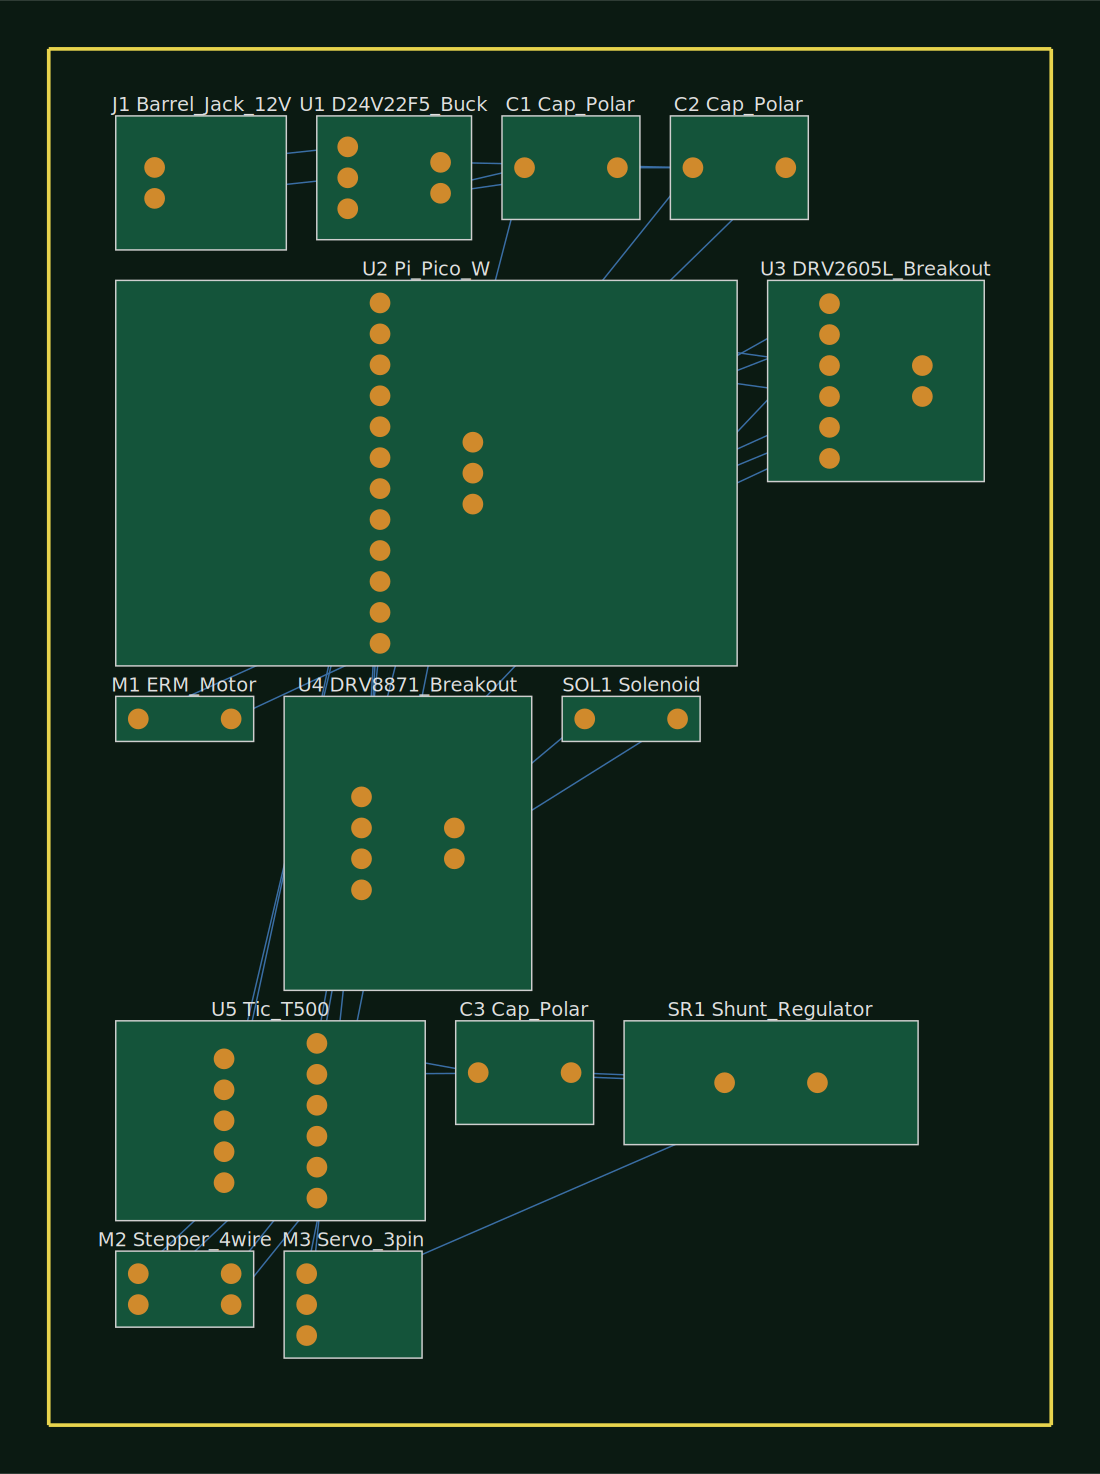

In [11]:
# Quick look at the SVG to verify the placement visually matches our model
from IPython.display import SVG, display
display(SVG(f"{wd}/test_module_starter.svg"))

In [12]:
# SVG renders but inline display unclear; just confirm size
import os
print(os.path.getsize(f"{wd}/test_module_starter.svg"), "bytes")
# Read first 800 chars
print(open(f"{wd}/test_module_starter.svg").read()[:500])

10615 bytes
<svg xmlns="http://www.w3.org/2000/svg" width="1100" height="1474" viewBox="0 0 90.28 120.95">
<rect x="0" y="0" width="90.28" height="120.95" fill="#0b1a12"/>
<line x1="4.00" y1="4.00" x2="86.28" y2="4.00" stroke="#e8d44d" stroke-width="0.3"/>
<line x1="86.28" y1="4.00" x2="86.28" y2="116.95" stroke="#e8d44d" stroke-width="0.3"/>
<line x1="86.28" y1="116.95" x2="4.00" y2="116.95" stroke="#e8d44d" stroke-width="0.3"/>
<line x1="4.00" y1="116.95" x2="4.00" y2="4.00" stroke="#e8d44d" stroke-width=


In [13]:
# OK, board outline matches our calc. Now produce a clean answer.
# Comparison reference points for board size:
# - Arduino Mega: 101.5 × 53.3 mm
# - RPi 4: 85 × 56 mm
# - Pico W on the board alone occupies 51 × 21 mm = ~1071 mm² out of 9293 mm² total => 11.5% of board
print("Pico fraction of board:", 51*21/(82.28*112.95)*100)
# Components total area
total_body = 14*11 + 12.7*10.16 + 8.5*8.5*3 + 51*21 + 17.78*16.51 + 20.32*24.13 + 25.4*15.24 + 24.13*10.16
print(f"Sum of body areas (modules+passives): {total_body:.0f} mm^2")
print(f"Fraction: {total_body/(82.28*112.95)*100:.1f}%")


Pico fraction of board: 11.524151328570017
Sum of body areas (modules+passives): 2987 mm^2
Fraction: 32.1%


In [14]:
# Check total available area vs target area to ensure our metric interpretation is right
# Body area = ~32%, Courtyard area = ~46%. That's quite a comfortable board, plenty of room to route.
